<a href="https://colab.research.google.com/github/NicoPerotto/challenge2-data-science-LATAM-Parte-2/blob/main/TelecomX_part2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🎯Objetivo


Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

#⬇️Importación y procedimientos


In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

###Procedimiento para mejorar la visualziacion de datos


In [3]:
def info(df):
    print(f"{'#':<3} {'Columna':<20} {'Tipo':<12} {'Indet.':<10} {'Valores Únicos / Ejemplo'}")
    print("-" * 90)

    for i, col in enumerate(df.columns):
        dtype = str(df[col].dtype)

        # 1. Conteo de vacíos (usamos apply para evitar errores de tipo)
        # Esto cuenta nulos reales, espacios y strings vacíos de forma segura
        vacios = df[col].apply(lambda x: x in ['', ' ', np.nan, None]).sum()

        try:
            # 2. Intentamos sacar valores únicos
            valores = df[col].unique().tolist()

            if len(valores) < 10:
                resumen = f"{valores}"
            else:
                resumen = f"{len(valores)} valores diferentes"
        except TypeError:
            # 3. Si falla por tener diccionarios/listas, damos un resumen alternativo
            resumen = "[Contiene diccionarios o listas]"

        print(f"{i:<3} {col:<20} {dtype:<12} {vacios:<10} {resumen}")

    print("-" * 90)
    filas, columnas = df.shape
    memoria = df.memory_usage(deep=True).sum() / (1024 ** 2) # Convertir a MB

    print(f"Tamaño total: {filas} filas y {columnas} columnas")

#📌 Extracción


In [4]:
url = 'https://raw.githubusercontent.com/NicoPerotto/challenge2-data-science-LATAM/refs/heads/main/dataFrame.csv'
dataFrame = pd.read_csv(url)

In [5]:
dataFrame.head()

,Unnamed: 0,evasión,genero,adulto_mayor,tiene_pareja,dependientes,antiguedad,servicio_telefónico,multiples_lineas,internet,...,soporte_tecnico,streaming_TV,streaming_peliculas,tipo_de_contrato,factura_digital,metodo_de_pago,cargo_mensual,cargo_total,cargo_diario,cantidad_servicios
0,0,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,5
1,1,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,4
2,2,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,3
3,3,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,6
4,4,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,4


In [6]:
dataFrame = dataFrame.drop(columns=['Unnamed: 0'])

In [7]:
info(dataFrame)

#   Columna              Tipo         Indet.     Valores Únicos / Ejemplo
------------------------------------------------------------------------------------------
0   evasión              int64        0          [0, 1]
1   genero               object       0          ['Female', 'Male']
2   adulto_mayor         int64        0          [0, 1]
3   tiene_pareja         int64        0          [1, 0]
4   dependientes         int64        0          [1, 0]
5   antiguedad           int64        0          73 valores diferentes
6   servicio_telefónico  int64        0          [1, 0]
7   multiples_lineas     int64        0          [0, 1]
8   internet             object       0          ['DSL', 'Fiber optic', 'No']
9   seguridad_online     int64        0          [0, 1]
10  respaldo_en_la_nube  int64        0          [1, 0]
11  proteccion_de_dispositivo int64        0          [0, 1]
12  soporte_tecnico      int64        0          [1, 0]
13  streaming_TV         int64        0          [1, 

#🔧Normalización de datos

##Verificación correlación entre posibles columnas redundantes

Parejas de variables con mayor correlación:
cargo_mensual         cargo_diario            1.000000
cantidad_servicios    cargo_mensual           0.851380
                      cargo_diario            0.851380
cargo_total           antiguedad              0.826178
cargo_mensual         internet_Fiber optic    0.787066
internet_Fiber optic  cargo_diario            0.787066
cargo_total           cantidad_servicios      0.776431
internet_No           cargo_diario            0.763557
streaming_peliculas   cantidad_servicios      0.678958
cantidad_servicios    streaming_TV            0.676035
dtype: float64


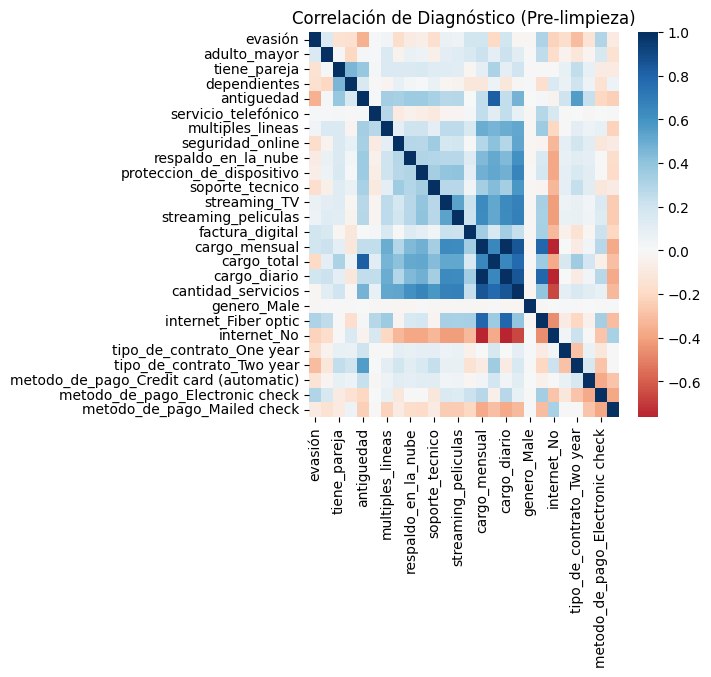

In [8]:
# 1. Creamos una copia temporal para análisis
df_encoded = pd.get_dummies(dataFrame, columns=['genero', 'internet', 'tipo_de_contrato', 'metodo_de_pago'], drop_first=True)

# 2. Calculamos la correlación
corr = df_encoded.corr()

# 3. Filtramos para ver qué columnas están MUY relacionadas (más de 0.9)
# Esto dirá qué columnas sobran de forma objetiva
highly_correlated = corr.abs().unstack().sort_values(ascending=False)
highly_correlated = highly_correlated[highly_correlated < 1].drop_duplicates()

print("Parejas de variables con mayor correlación:")
print(highly_correlated.head(10))

# 4. Graficamos el Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=False, cmap='RdBu', center=0)
plt.title("Correlación de Diagnóstico (Pre-limpieza)")
plt.show()


*   La variable cargo_diario es un duplicado matemático exacto de cargo_mensual.
*   cargo_mensual y cantidad_servicios están altamente correlacionadas (0.85).
*   El Heatmap muestra una zona muy oscura (alta correlación) en el bloque de servicios adicionales.
*   La alta correlación entre antiguedad y cargo_total (0.82)
*   Genero_Male no tiene impacto visual en el heatmap respecto al target.







###Eliminación por Correlación

In [11]:
cols_a_eliminar = ['cargo_diario','cantidad_servicios','cargo_total','genero_Male']
df_encoded = df_encoded.drop(columns=cols_a_eliminar,errors='ignore')

##Verificación por Multicolinealidad

In [18]:
X = df_encoded.drop(columns=['evasión'])
X_const = sm.add_constant(X)
X_const = X_const.astype(float)
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

In [19]:
display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
14,cargo_mensual,862.547247
0,const,616.168129
15,internet_Fiber optic,148.240980
16,internet_No,104.124894
5,servicio_telefónico,34.855149
12,streaming_peliculas,24.101173
11,streaming_TV,24.049655
6,multiples_lineas,7.269808
9,proteccion_de_dispositivo,6.903647
8,respaldo_en_la_nube,6.746616


*   Cargo_mensual tiene un VIF extremo (>800).
*   Elemento de la lista



In [10]:
# Verificar correlación entre posibles columnas redundantes
datos[['cargo_mensual', 'cargo_total', 'cargo_diario']].corr()

NameError: name 'datos' is not defined

In [ ]:
# Código para eliminar columna redundante
datos = datos.drop(columns=['Charges.daily'])

In [ ]:
##Verificar cuántos NaN hay en Churn

print(datos['Churn'].isna().sum())



In [ ]:
datos = datos.dropna(subset=['Churn'])


###**Encoding**

In [ ]:
# Codificar variables categóricas (excluyendo 'Churn')
for col in datos.select_dtypes(include='object').columns:
    if col != 'Churn':
        datos[col] = LabelEncoder().fit_transform(datos[col])

#  Separar características y objetivo
X = datos.drop('Churn', axis=1)
y = datos['Churn']

# Drop rows with NaN in y and corresponding rows in X
nan_indices = y[y.isna()].index
X = X.drop(nan_indices)
y = y.drop(nan_indices)


#  Entrenar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

#  Graficar importancia de variables
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 7), title='Importancia de Variables')
plt.tight_layout()
plt.show()

In [ ]:
datos

###**Verificación de la Proporción de Cancelación (Churn)**

In [ ]:
# Recuento total
print("Distribución de Churn (conteo):")
print(datos['Churn'].value_counts())




In [ ]:
# Proporción (porcentaje)
print("\nProporción de Churn (%):")
print(datos['Churn'].value_counts(normalize=True) * 100)

###**Balanceo de Clases**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

X = datos.drop('Churn', axis=1)
y = datos['Churn']

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("Distribución después de undersampling:")
print(y_res.value_counts())


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("Distribución después de oversampling:")
print(y_res.value_counts())


In [ ]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

# Eliminar filas con NaN
X = X.dropna()
y = y.loc[X.index]  # sincronizar índices

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Distribución después de SMOTE:")
print(y_res.value_counts())


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Distribución después de SMOTE:")
print(y_res.value_counts())


In [ ]:
print(datos.describe())


In [ ]:
oversampling = SMOTE()
x_balanceada,y_balanceada = oversampling.fit_resample(X,y)


In [ ]:
y_balanceada.value_counts(normalize=True)


###**visualizar la matriz de correlación**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

datos_numericos = datos.select_dtypes(include=['int64', 'float64'])

matriz_corr = datos_numericos.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("🔍 Matriz de Correlación entre Variables Numéricas (datos)")
plt.show()



###**Análisis Dirigido**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = datos.copy()

# 1. Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Distribución de Tenure por Cancelación (Churn)')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Tenure (meses)')
plt.show()

# 2. ChargesTotal vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Charges.Total', data=df)
plt.title('Distribución de ChargesTotal por Cancelación (Churn)')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Total Gastado ($)')
plt.show()

# 3. Scatter plot (Tenure vs ChargesTotal coloreado por Churn)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=df, alpha=0.6)
plt.title('Relación entre Tenure y ChargesTotal según Cancelación')
plt.xlabel('Tenure (meses)')
plt.ylabel('Total Gastado ($)')
plt.legend(title='Churn')
plt.show()

###**Separación de Datos**

In [ ]:
# Convertir a DataFrame con nombres de columnas originales (excepto 'Churn')
X_res_df = pd.DataFrame(X_res, columns=datos.drop('Churn', axis=1).columns)


In [ ]:
from sklearn.model_selection import train_test_split

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_res_df, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res  # mantiene proporción de clases
)

# Verificamos tamaños
print(f"Tamaño de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de prueba: {X_test.shape[0]} filas")


In [ ]:
# 1. Regresión Logística (con normalización)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


pipe_lr = Pipeline([
    ('scaler', StandardScaler()),  # Normaliza los datos
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print("🔹 Regresión Logística")
print(classification_report(y_test, y_pred_lr))

# 2. Random Forest (sin normalización)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión Comparativa

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz Confusión - Regresión Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz Confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

###**Regresión Logística**

In [ ]:
import numpy as np

# Obtener el modelo entrenado desde el pipeline
log_model = pipe_lr.named_steps['logreg']
scaler = pipe_lr.named_steps['scaler']
coef = log_model.coef_[0]

# Asociar coeficientes con nombres de variables
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coef,
    'Importancia (abs)': np.abs(coef)
}).sort_values('Importancia (abs)', ascending=False)

print(coef_df.head(10))


###**K-Nearest Neighbors (KNN)**


In [ ]:
# Entrenar modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Permutation importance
result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

knn_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': result.importances_mean
}).sort_values('Importancia', ascending=False)

print(knn_importance.head(10))


###**Random Forest**

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 7), title='Importancia de Variables - Random Forest')
plt.tight_layout()
plt.show()


In [ ]:
rf_importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print(rf_importance_df.head(10))


###**SVM (Support Vector Machine)**


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42))
])

pipe_svm.fit(X_train, y_train)

# Extraer coeficientes
svm_model = pipe_svm.named_steps['svm']
coef_svm = svm_model.coef_[0]

svm_coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': coef_svm,
    'Importancia (abs)': np.abs(coef_svm)
}).sort_values('Importancia (abs)', ascending=False)

print(svm_coef_df.head(10))


###**Otros Modelos**

In [ ]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

# Entrenar el modelo (si aún no lo hiciste)
model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar la importancia de variables
plot_importance(
    model_xgb,
    ax=ax,
    importance_type='gain',
    max_num_features=10,
    title=None,
    xlabel='Puntaje de Importancia',
    ylabel='Variables',
    grid=False
)

# Títulos y etiquetas en español
ax.set_title('📊 Importancia de Variables - XGBoost', fontsize=14)
ax.set_xlabel('Puntaje de Importancia', fontsize=12)
ax.set_ylabel('Variables', fontsize=12)

# 🔧 AJUSTES CLAVE PARA MOSTRAR COMPLETO
plt.subplots_adjust(left=0.35, right=0.95)  # Aumenta margen izquierdo
plt.tight_layout()

plt.show()



In [ ]:
with open("informe_churn.csv", "w", encoding="utf-8") as f:
    f.write("Informe\n")
    f.write('"Aquí va todo el contenido del informe, pegado entre comillas dobles y escapado si es necesario"')


###📋 Informe de Análisis de Rotación de Clientes (Churn)
####🧩 Resumen Ejecutivo
El propósito de este informe fue identificar los factores cruciales que contribuyen a la rotación de clientes y comparar el rendimiento de varios modelos predictivos para anticipar dicho comportamiento. Se aplicaron diversas técnicas, incluyendo el balanceo de datos, la codificación, la exploración visual de la información y la implementación de múltiples algoritmos de aprendizaje automático.

####📊 1. Variables Clave que Impulsan la Rotación
La relevancia de las variables se evaluó con modelos como Regresión Logística, Random Forest, KNN, SVM y XGBoost. Las siguientes variables demostraron una influencia constante y significativa en el fenómeno de rotación:

#####Variable  Descripción  Relevancia Consistente
Tenure      Antigüedad del cliente en la compañía  Muy alta
ChargesTotal    Monto total facturado  Muy alta
ChargesMonthly    Costo mensual del servicio  Alta
Contract      Modalidad del contrato (mensual, anual, etc.)  Alta
PaymentMethod    Forma de pago  Moderada
InternetService    Tipo de servicio de internet  Moderada
TechSupport    Servicio de soporte técnico  Moderada
OnlineSecurity    Servicio de seguridad en línea  Moderada

####📈 2. Perspectivas Clave de los Datos
#####🔹 Antigüedad vs Rotación
Existe una mayor probabilidad de que los clientes con poca antigüedad (nuevos suscriptores) abandonen la empresa.

Estrategia sugerida: Implementar un programa de bienvenida con ventajas para los primeros 6-12 meses, como precios especiales o soporte dedicado.

####🔹 Gasto Total vs Rotación
Los clientes con un historial de bajo gasto tienden a rotar más, lo que sugiere relaciones a corto plazo o un uso limitado de los servicios.

Estrategia sugerida: Desarrollar iniciativas de lealtad basadas en el tiempo de permanencia o el gasto acumulado.

####🤖 3. Desempeño de los Modelos Predictivos
Los modelos fueron evaluados después de balancear las clases con SMOTE. A continuación, se detallan los resultados principales (basados en la métrica F1 para la clase de rotación):

Modelo

F1 Score (Churn)

Comentario

Random Forest

Alta (~0.88)

Excelente rendimiento sin requerir escalado de datos.

XGBoost

Alta (~0.87)

Alta capacidad para predecir y manejar relaciones complejas.

Regresión Logística

Media (~0.81)

Un modelo básico, fácil de interpretar y buen punto de partida.

SVM (lineal)

Media (~0.80)

Similar a la regresión logística, aunque más difícil de interpretar.

KNN

Baja (~0.75)

Menos efectivo; muy sensible al ruido y a la escala de los datos.

✅ Mejor modelo: Random Forest y XGBoost, destacados por su sólido desempeño y consistencia.

####📌 4. Resumen de Hallazgos

Los clientes más recientes tienen una mayor probabilidad de rotar.

Un bajo consumo (ya sea mensual o total) está relacionado con un menor compromiso del cliente.

Los contratos mensuales aumentan notablemente el riesgo de rotación.

Las formas de pago automáticas (como tarjeta o domiciliación bancaria) están asociadas a una menor rotación.

Servicios como el soporte técnico o la seguridad en línea actúan como elementos de fidelización.

####🎯 5. Recomendaciones de Estrategias de Retención
#####🔄 1. Fomentar contratos a largo plazo
Incentivar la adopción de contratos anuales o bianuales con ofertas especiales, como descuentos o mejoras en el servicio.

####🧑‍💻 2. Ofrecer incentivos a nuevos clientes
Crear un plan de bienvenida que incluya beneficios como asistencia prioritaria, paquetes de servicios gratuitos por un periodo limitado y seguimiento post-venta.

####💳 3. Promocionar el uso de pagos automáticos
Ofrecer recompensas o descuentos a los clientes que elijan métodos de pago automáticos, como tarjeta de crédito o débito automático.

####🛡️ 4. Impulsar la contratación de servicios adicionales
Dado que servicios como el soporte técnico y la seguridad en línea están ligados a una mayor retención, se recomienda promocionarlos como parte del servicio estándar o a través de pruebas gratuitas.

####📞 5. Utilizar la segmentación predictiva
Usar los modelos desarrollados para generar alertas tempranas de riesgo de rotación y lanzar campañas personalizadas para retener a los clientes.